# 随机森林就是多个决策树加权
核心特点
1. 由很多棵决策树组成：不是单靠一棵树，而是多个模型一起工作。
2. 每棵树都是随机训练的：
  - 训练数据是随机抽样的（每棵树可能看到的数据都不一样）。
  - 选择特征（决定如何分裂树的条件）时也是随机挑选的。
3. 最终结果是所有树的预测值的平均值，这样能减少单个模型的过拟合问题，提高泛化能力。

单棵回归决策树
随机森林是由多棵 **回归决策树（Regression Tree）** 组成，因此先回顾决策树回归的数学原理。
回归树的目标
给定一个训练数据集：
$D = \{(x_1, y_1), (x_2, y_2), ..., (x_N, y_N)\}$
其中，$ x_i \in \mathbb{R}^d $是输入特征，$ y_i \in \mathbb{R} $是对应的目标变量。
我们希望构建一个决策树来将输入特征空间划分成多个区域 $R_m $，并在每个区域内用均值作为预测值：
$f(x) = \sum_{m=1}^{M} c_m \cdot \mathbb{I}(x \in R_m)$
其中：
$R_m $是决策树分割出来的区域。
$c_m $是该区域内所有样本 $y_i $的均值：
$c_m = \frac{1}{|R_m|} \sum_{x_i \in R_m} y_i$
$\mathbb{I}(x \in R_m) $是指示函数，表示样本 $x $是否属于区域 $R_m $。
决策树的划分标准
构造决策树时，我们需要在某个特征 $j $上选择一个最佳分割点 $s $，使得目标函数最优（最小化方差）。
对于一个分割点 $s $，数据被划分为左右两个区域：
$R_{\text{left}}(j, s) = \{x_i | x_{ij} \leq s\}, \quad R_{\text{right}}(j, s) = \{x_i | x_{ij} > s\}$
我们希望选择一个 $(j, s) $使得目标函数（均方误差，MSE）最小：
$\underset{j, s}{\arg\min} \left[ \sum_{x_i \in R_{\text{left}}} (y_i - c_{\text{left}})^2 + \sum_{x_i \in R_{\text{right}}} (y_i - c_{\text{right}})^2 \right]$
其中：
$c_{\text{left}} = \frac{1}{|R_{\text{left}}|} \sum_{x_i \in R_{\text{left}}} y_i, \quad c_{\text{right}} = \frac{1}{|R_{\text{right}}|} \sum_{x_i \in R_{\text{right}}} y_i$
最终，我们使用递归的方法，逐步划分数据，直到满足停止条件（如最小叶子节点数、最大树深度等）。

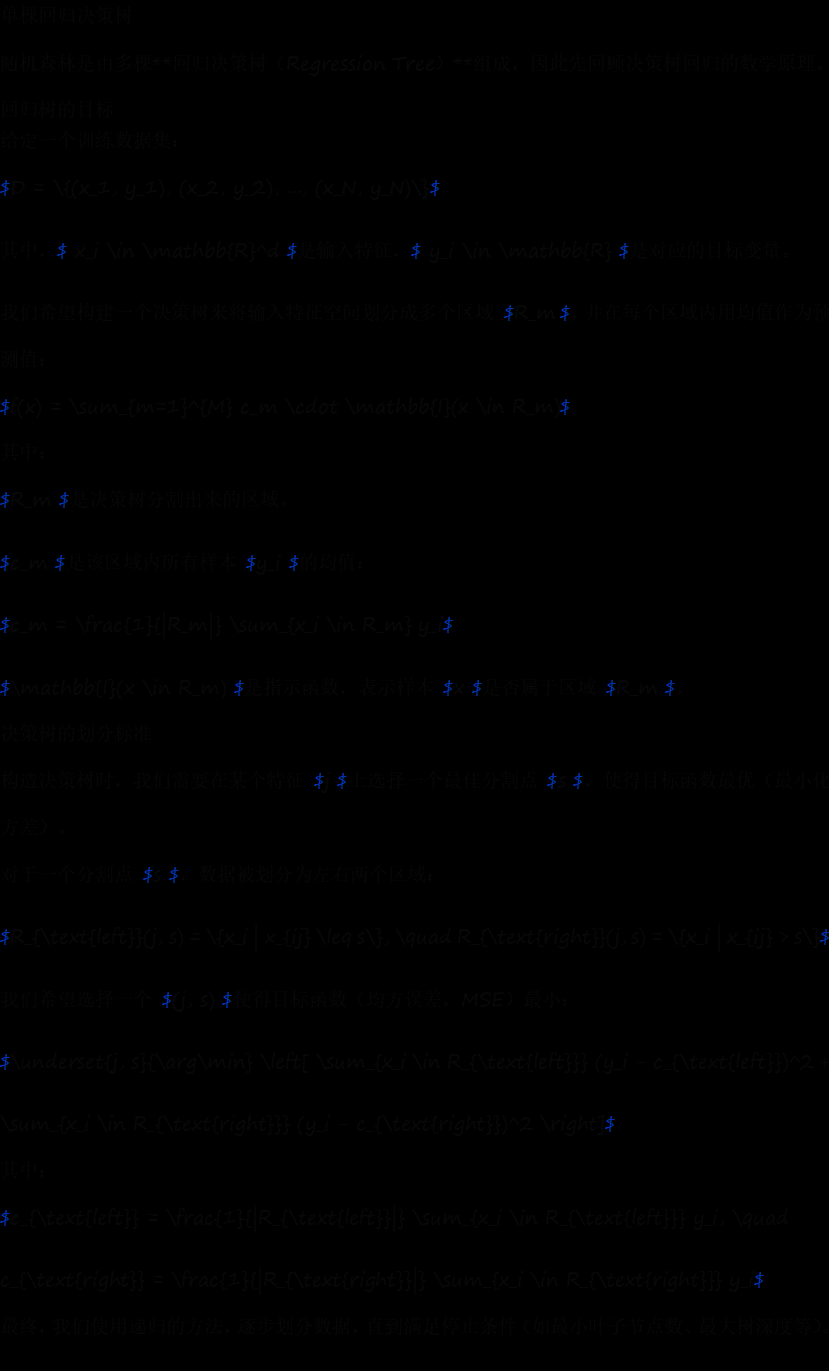
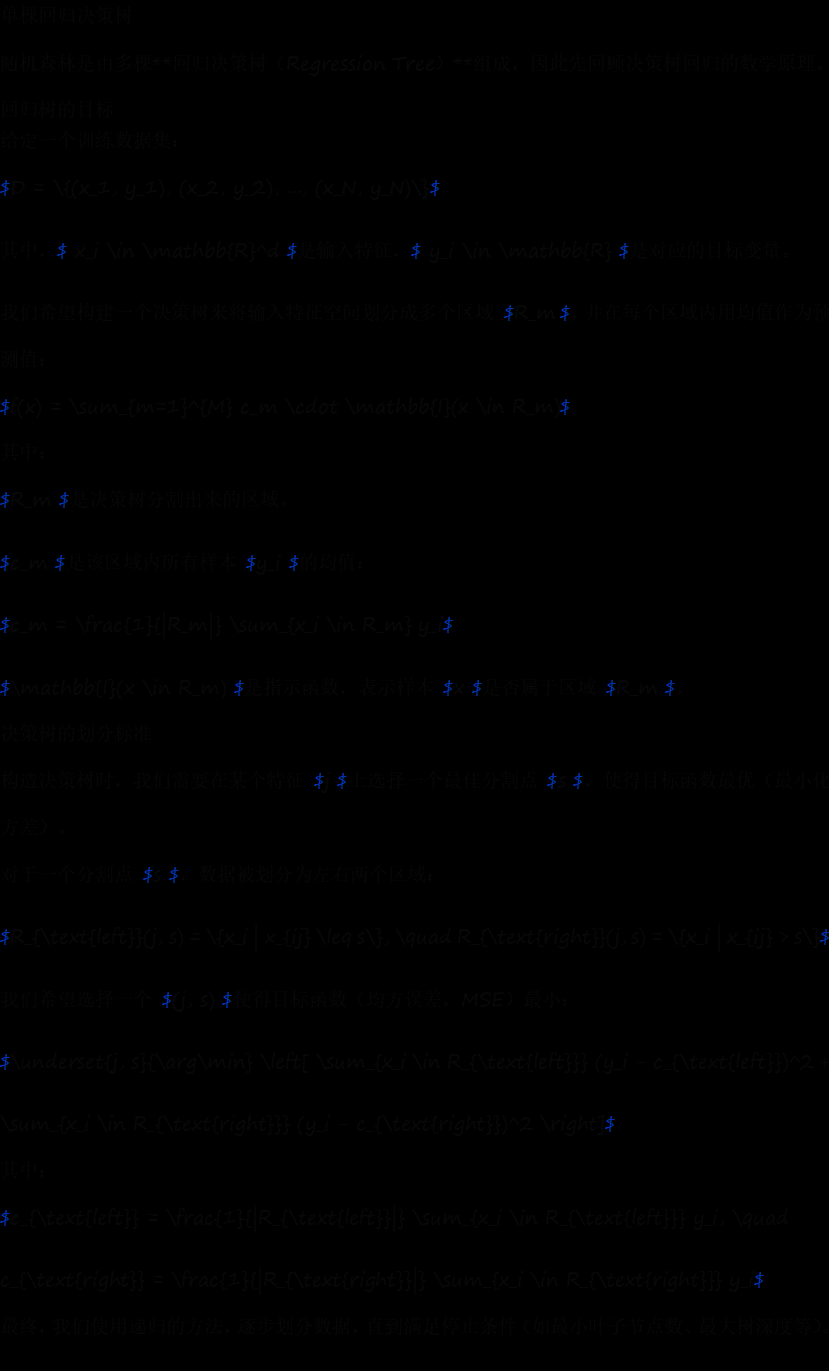

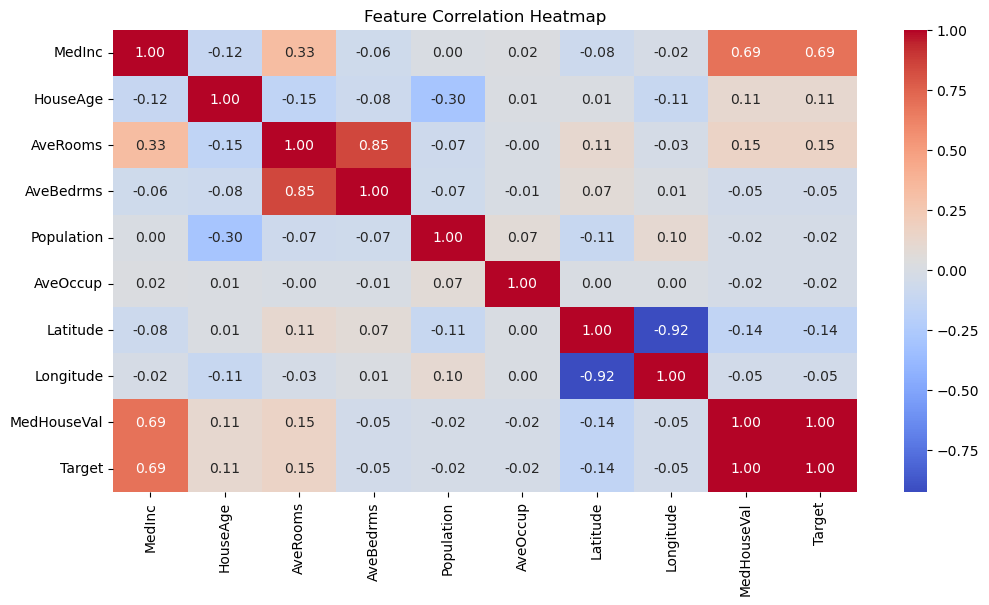

Mean Squared Error: 2571542838.41
R² Score: 0.80


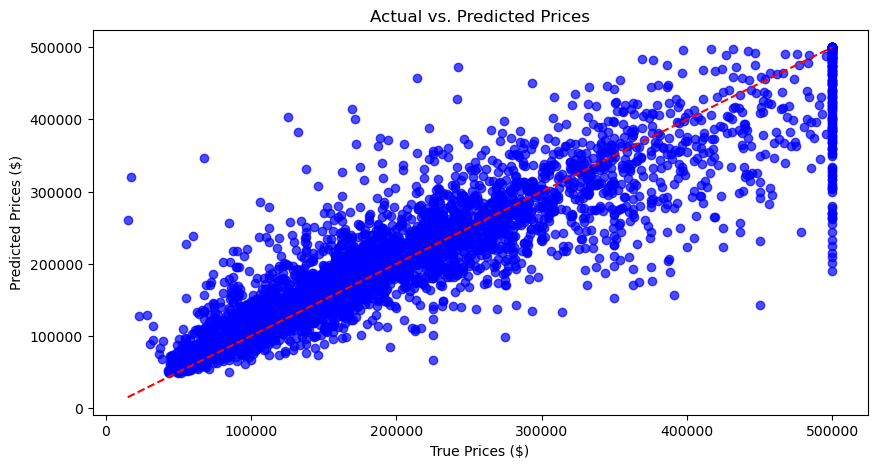

Optimized MSE: 2546149476.92
Optimized R²: 0.81


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. 加载加利福尼亚房价数据集
#data = fetch_california_housing()
#df = pd.DataFrame(data.data, columns=data.feature_names)
df = pd.read_csv("./fetched_california_housing.csv")
df["Target"] = df.MedHouseVal * 100000  # 转换单位（单位：美元）

# 2. 数据可视化
plt.figure(figsize=(12, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

# 3. 数据拆分
X = df.drop(columns=["Target","MedHouseVal"])
y = df["Target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. 训练随机森林回归模型
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# 5. 评估模型
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")

# 6. 结果可视化
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.7, color='b')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r')
plt.xlabel("True Prices ($)")
plt.ylabel("Predicted Prices ($)")
plt.title("Actual vs. Predicted Prices")
plt.show()

# 7. 超参数优化
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10]
}
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring="r2", n_jobs=-1)
grid_search.fit(X_train, y_train)

# 8. 使用最佳参数重新训练
best_rf = grid_search.best_estimator_
best_rf.fit(X_train, y_train)
y_pred_best = best_rf.predict(X_test)

# 9. 评估优化后模型
mse_best = mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)
print(f"Optimized MSE: {mse_best:.2f}")
print(f"Optimized R²: {r2_best:.2f}")

In [5]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
